## PHASE DE TEST - PROJET SCOPE DEEP LEARNING

In [11]:
#setup
!pip install nltk
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## download/preprocess

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import zipfile
import os
from PIL import Image

# Chemins vers les fichiers .zip sur Google Drive
dataset_zip = "/content/drive/MyDrive/Documents/Flickr8k_Dataset.zip"
captions_zip = "/content/drive/MyDrive/Documents/Flickr8k_text.zip"

# Extraction dans /content/
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/Flickr8k_Dataset")

with zipfile.ZipFile(captions_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/Flickr8k_text")

# Vérification du chemin d'une image
image_dir = "/content/Flickr8k_Dataset/Flicker8k_Dataset"
img_path = os.path.join(image_dir, "1000268201_693b08cb0e.jpg")

# Afficher l'image
img = Image.open(img_path)
img.show()


In [ ]:
!ls /content/drive


MyDrive


In [14]:
image_dir = "/content/Flickr8k_Dataset/Flicker8k_Dataset"
caption_file = "/content/Flickr8k_text/Flickr8k.token.txt"


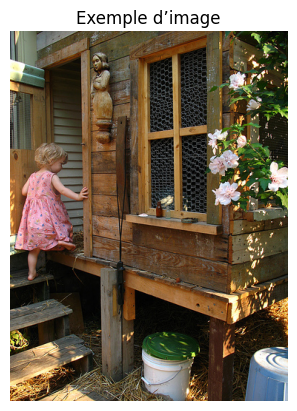

In [15]:
import matplotlib.pyplot as plt

img = Image.open(os.path.join(image_dir, "1000268201_693b08cb0e.jpg"))

plt.imshow(img)
plt.axis("off")
plt.title("Exemple d’image")
plt.show()


Étape 1 — Traitement des captions + vocabulaire

In [16]:
import os
from collections import Counter

caption_file = "/content/Flickr8k_text/Flickr8k.token.txt"

# Charger les captions
captions = {}
with open(caption_file, 'r') as f:
    for line in f:
        if len(line) < 2:
            continue
        img_id, caption = line.split('\t')
        img_id = img_id.split('#')[0].strip()  # ✅ enlève les espaces ET les .1, .2, etc.
        cleaned = caption.lower().strip().translate(
            str.maketrans('', '', '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~')
        )
        captions.setdefault(img_id, []).append(cleaned)

# Construire le vocabulaire
word_freq = Counter()
for cap_list in captions.values():
    for cap in cap_list:
        word_freq.update(cap.split())

min_freq = 5
vocab = [w for w in word_freq if word_freq[w] >= min_freq]
word2idx = {w: i+1 for i, w in enumerate(vocab)}
word2idx["<PAD>"] = 0
word2idx["<START>"] = len(word2idx)
word2idx["<END>"] = len(word2idx)
word2idx["<UNK>"] = len(word2idx)
idx2word = {i: w for w, i in word2idx.items()}


Étape 2 — Dataset PyTorch

In [17]:
import random
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
import torch

image_dir = "/content/Flickr8k_Dataset/Flicker8k_Dataset"
selected_imgs = list(captions.keys())

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

class FlickrDataset(Dataset):
    def __init__(self, image_ids):
        self.image_ids = image_ids
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(image_dir, img_id)
        image = self.transform(Image.open(img_path).convert("RGB"))
        tokens = ["<START>"] + captions[img_id][0].lower().strip().split() + ["<END>"]
        cap_idx = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]
        return image, torch.tensor(cap_idx)


Etape 3 — Modèle CNN + LSTM

In [18]:
import torch.nn as nn
import torchvision.models as models

class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)

    def forward(self, x):
        with torch.no_grad():
            x = self.backbone(x).squeeze()
        return self.fc(x)

class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, dropout=0.3)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        embeddings = self.embed(captions)
        features = features.unsqueeze(0).unsqueeze(1)
        inputs = torch.cat((features, embeddings), dim=0)
        outputs, _ = self.lstm(inputs)
        return self.linear(outputs)



dataloader

In [19]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    images, captions = zip(*batch)
    captions = pad_sequence(captions, padding_value=word2idx["<PAD>"])
    return torch.stack(images), captions

dataloader = DataLoader(
    FlickrDataset(selected_imgs),
    batch_size=1,
    shuffle=True,
    collate_fn=collate_fn
)


entrainement

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
encoder = EncoderCNN(embed_size=256).to(device)
decoder = DecoderLSTM(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

for epoch in range(15):
    total_loss = 0
    for img, cap in dataloader:
        img, cap = img.to(device), cap.to(device)
        features = encoder(img)
        outputs = decoder(features, cap[:-1])   # (seq_len, batch, vocab_size)
        outputs = outputs[1:]                   # Ignore la sortie liée à l'image
        loss = criterion(outputs.view(-1, len(word2idx)), cap[1:].view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")



/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Génération de caption + affichage

In [ ]:
def generate_caption(image_tensor):
    with torch.no_grad():
        feat = encoder(image_tensor.unsqueeze(0).to(device))
        caption = [word2idx["<START>"]]
        for _ in range(20):
            inp = torch.tensor(caption).unsqueeze(1).to(device)
            out = decoder(feat, inp)
            next_word = out.argmax(2)[-1].item()
            if next_word == word2idx["<END>"]:
                break
            caption.append(next_word)
    return ' '.join([idx2word.get(i, "<UNK>") for i in caption[1:]])


calcul du bleu

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_caption(img_id):
    image = transform(Image.open(os.path.join(image_dir, img_id)).convert("RGB"))
    image_tensor = image.to(device)
    generated = generate_caption(image_tensor)

    # Récupère les vraies captions
    references = [cap.lower().strip().split() for cap in captions[img_id]]
    candidate = generated.strip().split()

    bleu = sentence_bleu(references, candidate, smoothing_function=SmoothingFunction().method4)
    return bleu, generated


encoder CNN avec sortie spatiale (pour attention)

In [ ]:
import torch.nn as nn
import torchvision.models as models

class EncoderCNN(nn.Module):
    def __init__(self, encoded_size=14):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # conserve jusqu'à la dernière conv
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_size, encoded_size))  # output: (B, 2048, 14, 14)

    def forward(self, x):
        x = self.backbone(x)              # (B, 2048, H, W)
        x = self.adaptive_pool(x)         # (B, 2048, 14, 14)
        x = x.permute(0, 2, 3, 1)         # (B, 14, 14, 2048)
        x = x.view(x.size(0), -1, x.size(-1))  # (B, 196, 2048)
        return x


Attention module (Bahdanau style)

In [ ]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att = nn.Linear(encoder_dim, attention_dim)
        self.dec_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden_state):
        # encoder_out: (B, num_pixels, encoder_dim)
        # hidden_state: (B, decoder_dim)
        att1 = self.enc_att(encoder_out)                      # (B, num_pixels, att_dim)
        att2 = self.dec_att(hidden_state).unsqueeze(1)        # (B, 1, att_dim)
        e = torch.tanh(att1 + att2)                           # (B, num_pixels, att_dim)
        alpha = self.full_att(e).squeeze(2)                   # (B, num_pixels)
        alpha = torch.softmax(alpha, dim=1)                   # (B, num_pixels)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, encoder_dim)
        return context, alpha


3. DecoderLSTM avec Attention

In [ ]:
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, decoder_dim, vocab_size, encoder_dim=2048, attention_dim=256):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        embeddings = self.embed(captions).permute(1, 0, 2)  # (seq_len, B, embed)
        h, c = self.init_hidden_state(batch_size)

        outputs = []
        for t in range(embeddings.size(0)):
            context, _ = self.attention(encoder_out, h)                     # (B, encoder_dim)
            lstm_input = torch.cat([embeddings[t], context], dim=1)        # (B, embed + enc_dim)
            h, c = self.lstm(lstm_input, (h, c))                            # (B, dec_dim)
            output = self.fc(self.dropout(h))                              # (B, vocab)
            outputs.append(output)

        outputs = torch.stack(outputs, dim=0)  # (seq_len, B, vocab)
        return outputs

    def init_hidden_state(self, batch_size):
        return (
            torch.zeros(batch_size, self.decoder_dim).to(next(self.parameters()).device),
            torch.zeros(batch_size, self.decoder_dim).to(next(self.parameters()).device)
        )


dataloader

In [ ]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    images, captions = zip(*batch)
    captions = pad_sequence(captions, padding_value=word2idx["<PAD>"])
    return torch.stack(images), captions

dataloader = DataLoader(
    FlickrDataset(selected_imgs),  # dataset déjà préparé
    batch_size=1,
    shuffle=True,
    collate_fn=collate_fn
)


entrainement

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

encoder = EncoderCNN().to(device)
decoder = DecoderLSTM(
    embed_size=256,
    decoder_dim=512,
    vocab_size=len(word2idx),
    encoder_dim=2048,
    attention_dim=256
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

for epoch in range(15):  # n'hésite pas à monter si nécessaire
    total_loss = 0
    for img, cap in dataloader:
        img, cap = img.to(device), cap.to(device)

        encoder_out = encoder(img)             # (B, 196, 2048)
        outputs = decoder(encoder_out, cap[:-1])  # (seq_len, B, vocab)

        loss = criterion(outputs.view(-1, outputs.size(-1)), cap[1:].view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {total_loss:.4f}")


generation d'une caption avec attention

In [ ]:
def generate_caption_attention(image_tensor, max_len=20):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_out = encoder(image_tensor.unsqueeze(0).to(device))  # (1, 196, 2048)
        h, c = decoder.init_hidden_state(batch_size=1)

        caption = [word2idx["<START>"]]
        generated_words = []

        for _ in range(max_len):
            last_word = torch.tensor([caption[-1]]).to(device)
            embedding = decoder.embed(last_word)                     # (1, embed)
            context, _ = decoder.attention(encoder_out, h)          # (1, 2048)
            lstm_input = torch.cat([embedding, context], dim=1)     # (1, embed+2048)
            h, c = decoder.lstm(lstm_input, (h, c))                  # (1, hidden)
            output = decoder.fc(h)                                   # (1, vocab)
            predicted = output.argmax(1).item()
            if predicted == word2idx["<END>"]:
                break
            generated_words.append(idx2word.get(predicted, "<UNK>"))
            caption.append(predicted)

    return ' '.join(generated_words)


bleu score

In [ ]:
def evaluate_caption_attention(img_id):
    image = transform(Image.open(os.path.join(image_dir, img_id)).convert("RGB"))
    image_tensor = image.to(device)
    generated = generate_caption_attention(image_tensor)

    references = [cap.lower().strip().split() for cap in captions[img_id]]
    candidate = generated.strip().split()
    bleu = sentence_bleu(references, candidate, smoothing_function=SmoothingFunction().method4)
    return bleu, generated


In [ ]:
total_bleu = 0
print("🔍 BLEU score avec attention :\n")

for i, img_id in enumerate(selected_imgs[:10]):
    bleu, generated = evaluate_caption_attention(img_id)
    total_bleu += bleu
    print(f"{i+1}. 📷 {img_id}")
    print(f"   🧠 Caption générée : {generated}")
    print(f"   📊 BLEU score     : {bleu:.4f}\n")

print(f"✅ Score BLEU moyen (attention) : {total_bleu / 10:.4f}")
